<a href="https://colab.research.google.com/github/maxmigue/machineLearning/blob/main/ProyectoFinalML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final - Machine Learning 🧠** | **Clasificación de ritmo cardiaco 🖤**
---

> Miguel Contardo Ramos - 12/06/2025

---


# **Contexto:**

- La	fibrilación	auricular	es	una	condición	en	la	que	el	corazón	late	de	forma	irregular.
- Detectarla	a	tiempo	es	clave	para	prevenir	complicaciones.	En	este	proyecto,	se trabajará	con
señales	reales	de	electrocardiograma	(ECG), desarrollando un clasificador automático	para
distinguir distintos ritmos según la afección y dar un resultado al usuario: si una lectura de ECG pertenece al tipo Normal o se presenta una Fibrosis.

# **⛵ Entrega N°1: Exploración inicial**
---


## **1. Datos a trabajar**
- En este caso, se trabajará con archivos .mat (Para almacenar datos que se utilizan en un contexto *MATLAB*) y .hea (archivos de texto que sirven como encabezado para archivos de señal en el formato de archivo WFDB *(Waveform Database Format)*).
- Cada electrocardiograma tiene un archivo .mat y otro .hea, los cuales deben utilizarse en conjunto para obtener tanto la visualización como los datos de la lectura.

In [12]:
# Instalación de bibliotecas necesarias:
%pip install wfdb matplotlib neurokit2 scipy
%pip install PyWavelets


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\maxoO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 4.2/4.2 MB 42.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\maxoO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---

- En el siguiente fragmento, se realiza una visualización comparativa entre un ECG con resultado Normal y uno con Fibrosis Auricular, para ver con el tipo de dato que estamos trabajando, además de capturar los siguientes atributos en cuanto a los intervalos RR:
1. **mean_rr:** Promedio.
2. **std_rr:**  Desviación estándar.
3. **skew_rr:** Asimetría.
4. **kurt_rr:** Curtosis.

> Los intervalos RR son medidos en segundos (s), y representan la diferencia de tiempo entre picos R dentro de un ECG (En la siguiente imagen se representa en color rojo)

![RR-Interval](https://cerebromedico.com/wp-content/uploads/2018/10/Intervalo-QT-y-RR.png)

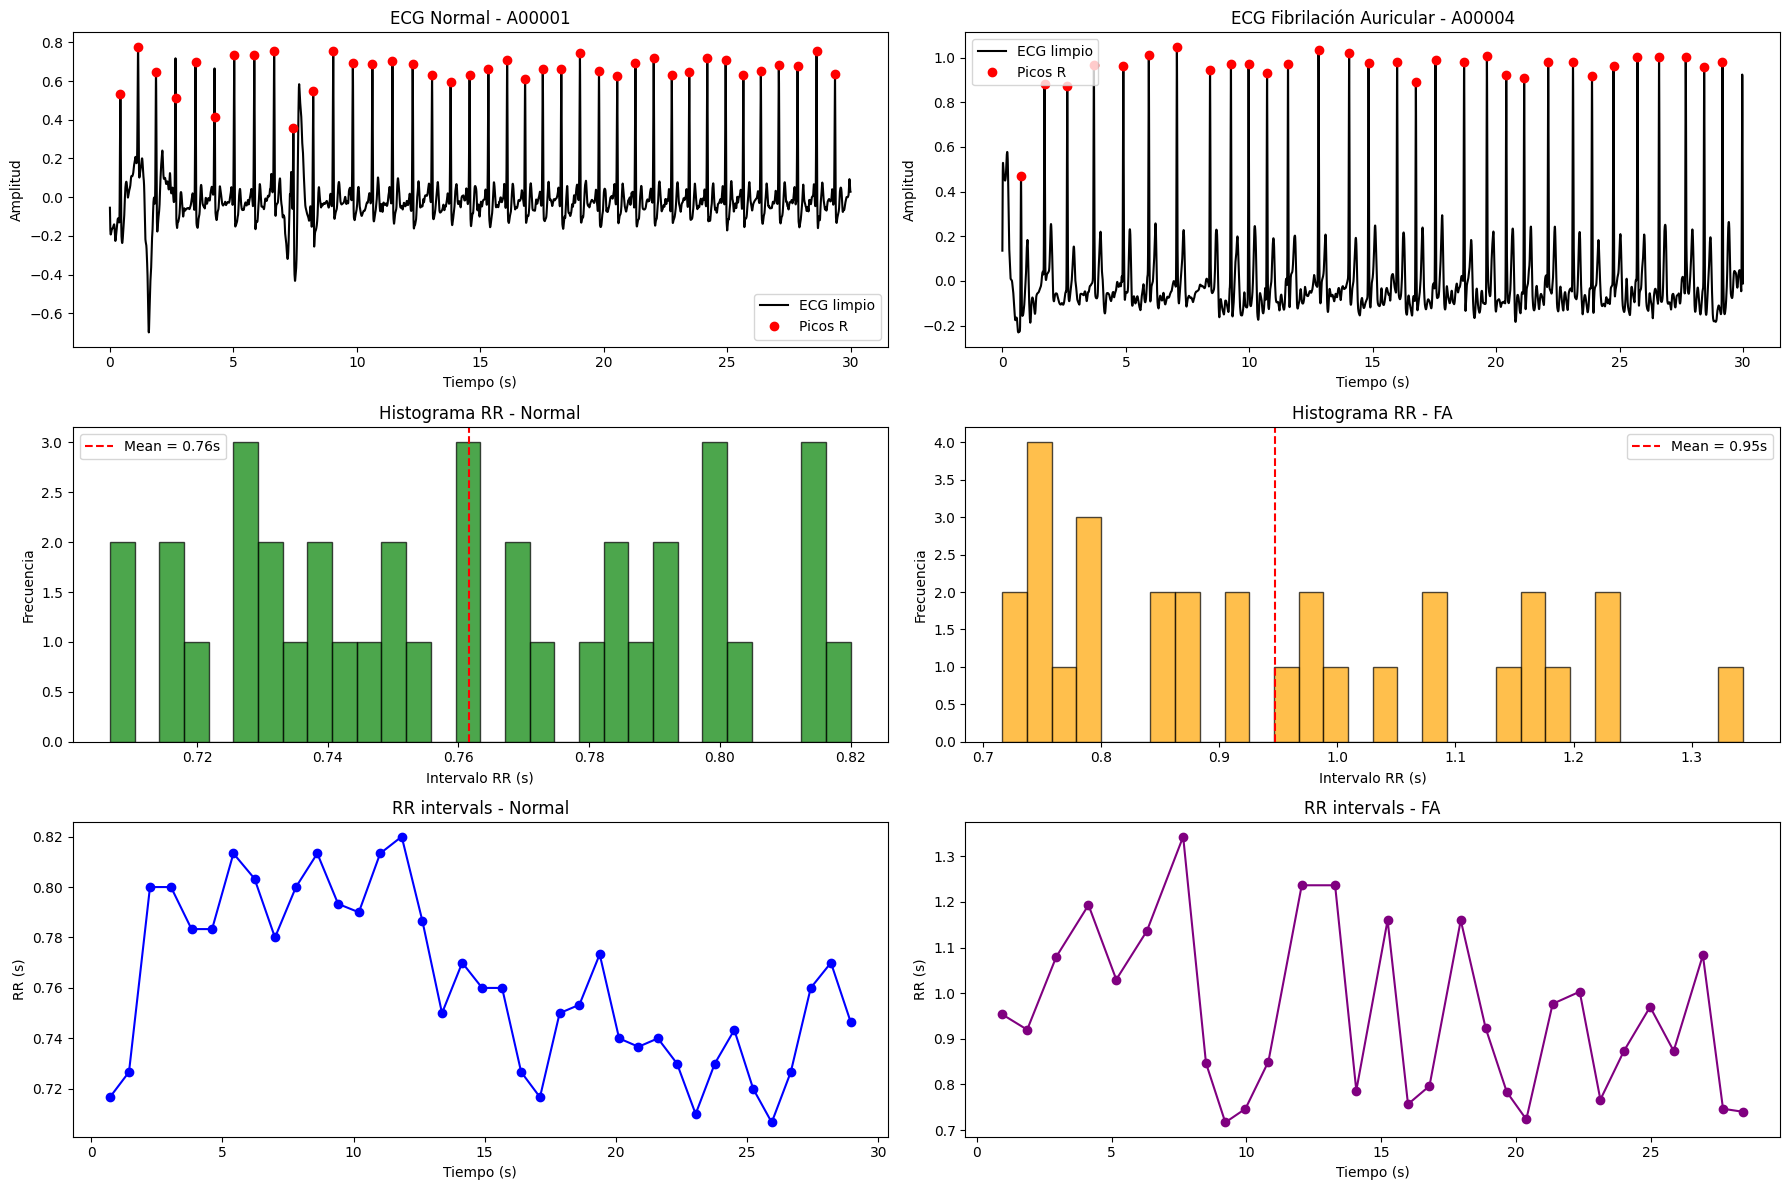


📊 Comparativa de estadísticas RR:

                 Mean RR (s)  STD RR (s)    Skew  Kurtosis
Normal (A00001)       0.7617      0.0329  0.1126   -1.2041
FA (A00004)           0.9471      0.1790  0.4735   -0.9432


In [9]:
import wfdb
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import pandas as pd

# Función para procesar un ECG
def procesar_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    ecg = record.p_signal[:, 0]
    fs = record.fs
    ecg_clean = nk.ecg_clean(ecg, sampling_rate=fs)
    _, info = nk.ecg_process(ecg_clean, sampling_rate=fs)
    r_peaks = info['ECG_R_Peaks']
    rr = np.diff(r_peaks) / fs
    return ecg_clean, r_peaks, rr, fs

# Cargar ambos registros (Normal y Fibrosis Auricular)
ecg_normal, rpeaks_n, rr_n, fs_n = procesar_ecg('./data/ProyectoFinal/training2017/A00001')
ecg_afib,  rpeaks_a, rr_a, fs_a = procesar_ecg('./data/ProyectoFinal/training2017/A00004')

# Estadísticas
def stats(rr):
    return {
        'Mean RR (s)': np.mean(rr),
        'STD RR (s)': np.std(rr),
        'Skew': skew(rr),
        'Kurtosis': kurtosis(rr),
    }

stats_n = stats(rr_n)
stats_a = stats(rr_a)
df_stats = pd.DataFrame([stats_n, stats_a], index=["Normal (A00001)", "FA (A00004)"])

# ----------- GRAFICAS -----------

plt.figure(figsize=(18, 12))

# ECG limpios
plt.subplot(3, 2, 1)
time_n = np.arange(len(ecg_normal)) / fs_n
plt.plot(time_n, ecg_normal, label="ECG limpio", color='black')
plt.plot(rpeaks_n / fs_n, ecg_normal[rpeaks_n], 'ro', label="Picos R")
plt.title("ECG Normal - A00001")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()

plt.subplot(3, 2, 2)
time_a = np.arange(len(ecg_afib)) / fs_a
plt.plot(time_a, ecg_afib, label="ECG limpio", color='black')
plt.plot(rpeaks_a / fs_a, ecg_afib[rpeaks_a], 'ro', label="Picos R")
plt.title("ECG Fibrilación Auricular - A00004")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()

# Histogramas RR
plt.subplot(3, 2, 3)
plt.hist(rr_n, bins=30, color='green', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(rr_n), color='red', linestyle='--', label=f'Mean = {np.mean(rr_n):.2f}s')
plt.title("Histograma RR - Normal")
plt.xlabel("Intervalo RR (s)")
plt.ylabel("Frecuencia")
plt.legend()

plt.subplot(3, 2, 4)
plt.hist(rr_a, bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(rr_a), color='red', linestyle='--', label=f'Mean = {np.mean(rr_a):.2f}s')
plt.title("Histograma RR - FA")
plt.xlabel("Intervalo RR (s)")
plt.ylabel("Frecuencia")
plt.legend()

# Variabilidad RR
plt.subplot(3, 2, 5)
plt.plot(np.cumsum(rr_n), rr_n, marker='o', linestyle='-', color='blue')
plt.title("RR intervals - Normal")
plt.xlabel("Tiempo (s)")
plt.ylabel("RR (s)")

plt.subplot(3, 2, 6)
plt.plot(np.cumsum(rr_a), rr_a, marker='o', linestyle='-', color='purple')
plt.title("RR intervals - FA")
plt.xlabel("Tiempo (s)")
plt.ylabel("RR (s)")

plt.tight_layout()
plt.show()

# ----------- COMPARATIVA -----------

print("\n📊 Comparativa de estadísticas RR:\n")
print(df_stats.round(4))


- Al ver la gráfica comparativa, podemos apreciar que las personas con Fibrosis presentan un pico R mayor al de aquellas personas cuyo resultado fue Normal, además, estas últimas poseen un rango menor de diferencia entre la duración de sus intervalos RR (0,12 aproximadamente), mientras que el paciente con afección cardiaca presenta un rango mucho mayor (0,7 aproximadamente).

---

## **2. Captura de features**

- Se aplicará una captura de ciertos atributos desprendidos de cada ECG, los cuales se guardarán de manera tabular en un archivo .csv, adjuntando además la clase/label de cada lectura.
- De esta manera, los datos quedan en un formato correcto para utilizar un modelo de ML tradicional (sin series de tiempo).
- En este punto, se generará un archivo .csv que contiene la tabla generada con los atributos y sus respectivos labels. Se utilizarán solamente lecturas que hayan dado como resultado "N" o "F", además, para tener un dataset balanceado, se guardarán 25 filas de cada clase.

> Convertimos los datos obtenidos a una forma tabular, así dejando el camino libre para aplicar un algoritmo de ML

In [34]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import skew, kurtosis
import neurokit2 as nk
import wfdb

# Rutas
data_dir = './data/ProyectoFinal/training2017/'
reference_path = os.path.join(data_dir, 'REFERENCE.csv')

# Leer referencia sin encabezado
ref_df = pd.read_csv(reference_path, header=None, names=["id", "clase"])

# Filtrar solo clases A y N
ref_df = ref_df[ref_df["clase"].isin(["A", "N"])]

# Limitar máximo 25 por clase
max_per_class = 25
df_filtered = pd.concat([
    ref_df[ref_df["clase"] == "A"].head(max_per_class),
    ref_df[ref_df["clase"] == "N"].head(max_per_class)
])

# Almacén de resultados
resultados = []

# Procesar registros válidos
for _, row in df_filtered.iterrows():
    record_name = row["id"]
    clase = row["clase"]

    mat_path = os.path.join(data_dir, record_name + '.mat')
    hea_path = os.path.join(data_dir, record_name + '.hea')

    try:
        # Cargar señal
        mat = loadmat(mat_path)
        signal = mat['val'][0]  # primer canal

        # Cargar metadatos
        record = wfdb.rdheader(os.path.join(data_dir, record_name))
        fs = record.fs

        # Limpiar y procesar señal
        ecg_cleaned = nk.ecg_clean(signal, sampling_rate=fs)
        _, info = nk.ecg_process(ecg_cleaned, sampling_rate=fs)

        # Calcular RR
        r_peaks = info["ECG_R_Peaks"]
        rr_intervals = np.diff(r_peaks) / fs

        # Validar condiciones antes de calcular estadísticas
        if (
            len(rr_intervals) >= 2 and
            np.all(np.isfinite(rr_intervals)) and
            np.any(rr_intervals != 0)
        ):
            mean_rr = float(np.mean(rr_intervals))
            std_rr = float(np.std(rr_intervals))
            skew_rr = float(skew(rr_intervals)) if std_rr != 0 else 0
            kurt_rr = float(kurtosis(rr_intervals)) if std_rr != 0 else 0
        else:
            mean_rr = 0
            std_rr = 0
            skew_rr = 0
            kurt_rr = 0

        resultados.append({
            "id": record_name,
            "mean_rr": mean_rr,
            "std_rr": std_rr,
            "skew_rr": skew_rr,
            "kurt_rr": kurt_rr,
            "label": clase
        })

    except Exception as e:
        print(f"Error en {record_name}: {e}")

# Crear DataFrame y guardar
df_resultados = pd.DataFrame(resultados)
df_resultados.set_index("id", inplace=True)

df_resultados.to_csv("resultados_filtrados.csv")
print(f"Resultados guardados en resultados_filtrados.csv con {len(df_resultados)} registros.")


Resultados guardados en resultados_filtrados.csv con 50 registros.


---

## **3. Visualización preliminar del dataset**

- Teniendo el dataset en formato .csv, lo podemos utilizar para entrenar un modelo de ML. Por ahora, se realiza la vista preliminar de los datos obtenidos y distintos gráficos en cuanto a las métricas obtenidas.

Primeras filas:
        id   mean_rr    std_rr   skew_rr   kurt_rr label
0  A00004  0.947111  0.179046  0.473546 -0.943222     A
1  A00005  0.538257  0.220187  1.220279  0.152991     A
2  A00009  0.634296  0.111982  0.400733 -0.360834     A
3  A00015  0.739744  0.237195  0.725895  0.710759     A
4  A00027  0.656364  0.120023  0.513638 -0.411462     A

Resumen estadístico:
          mean_rr     std_rr    skew_rr    kurt_rr
count  50.000000  50.000000  50.000000  50.000000
mean    0.806451   0.133455   0.229684   2.299071
std     0.185264   0.185818   1.580874   8.360011
min     0.478415   0.007513  -5.733077  -1.842882
25%     0.659593   0.051278  -0.282875  -0.603863
50%     0.792067   0.090629   0.336713  -0.226056
75%     0.939987   0.165812   0.787342   0.766445
max     1.368095   1.240707   5.681523  42.480822

Tipos de datos:
 id          object
mean_rr    float64
std_rr     float64
skew_rr    float64
kurt_rr    float64
label       object
dtype: object

Cantidad de registros por c

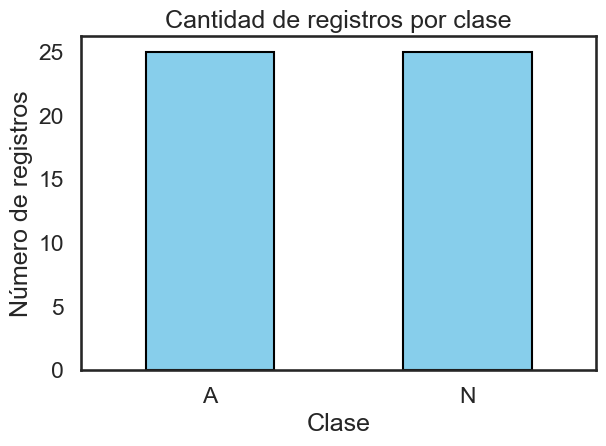

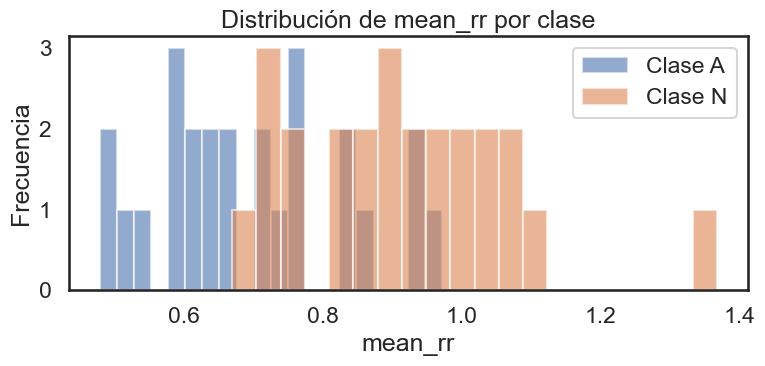

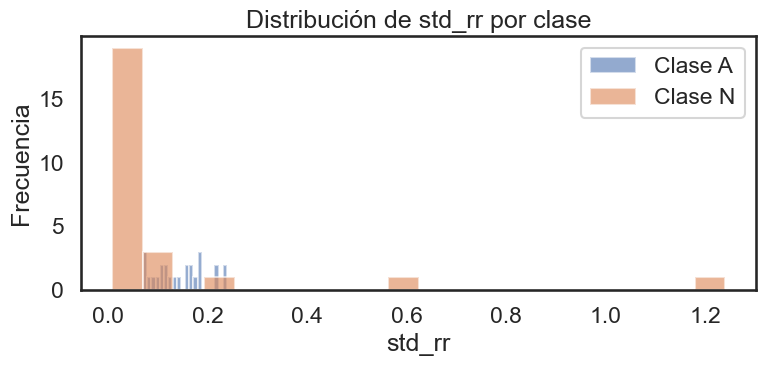

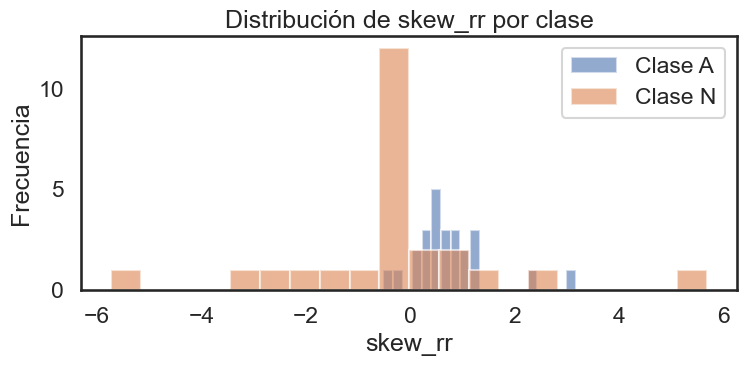

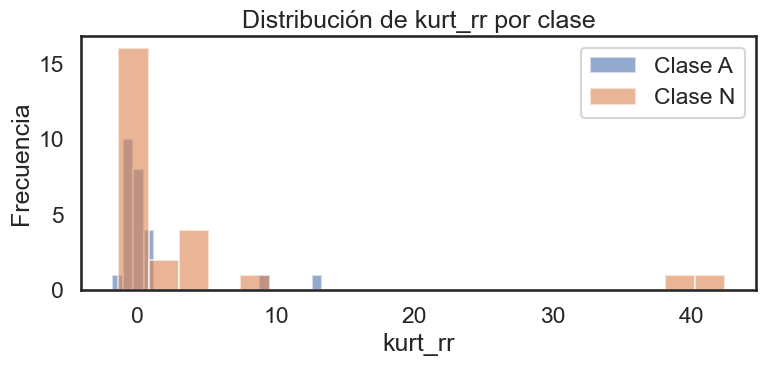

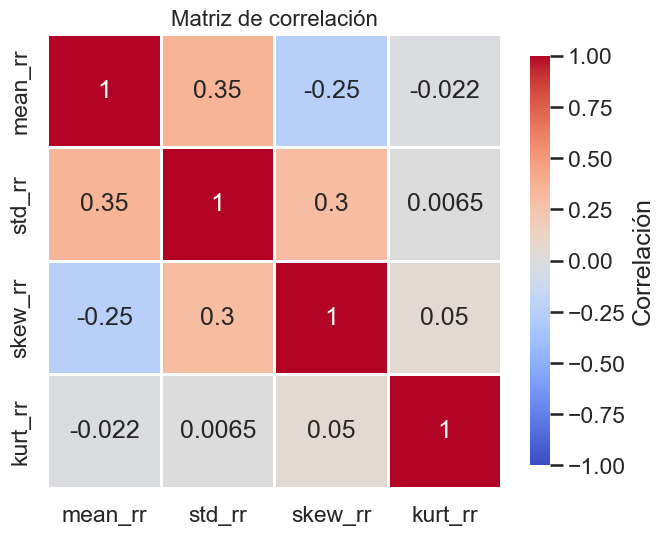

In [35]:
import seaborn as sns

# Cargar el CSV con resultados
df = pd.read_csv("resultados_filtrados.csv")

# Inspección básica
print("Primeras filas:\n", df.head())
print("\nResumen estadístico:\n", df.describe())
print("\nTipos de datos:\n", df.dtypes)

# Contar ocurrencias de cada clase
conteo_clases = df["label"].value_counts()
print("\nCantidad de registros por clase:")
print(conteo_clases)


conteo_clases.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Cantidad de registros por clase")
plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualizar distribuciones por clase
features = ["mean_rr", "std_rr", "skew_rr", "kurt_rr"]
clases = df["label"].unique()

# Histograma por clase
for feature in features:
    plt.figure(figsize=(8, 4))
    for clase in clases:
        subset = df[df["label"] == clase]
        plt.hist(subset[feature], bins=20, alpha=0.6, label=f"Clase {clase}")
    plt.title(f"Distribución de {feature} por clase")
    plt.xlabel(feature)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Matriz de correlación
corr = df[features].corr()

# Aplicar estilo de seaborn
sns.set_theme(style="white", context="talk") 

# Crear el gráfico
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={"shrink": 0.8, "label": "Correlación"}
)

plt.title("Matriz de correlación", fontsize=16)
plt.tight_layout()
plt.show()


---

## **4. Conclusiones**

- Se ha dejado un dataset balanceado por clase (25 lecturas cada una), lo cual es ideal para visualizar la información de manera fidedigna, además de que, al momento de entrenar un modelo de ML, este aspecto es muy importante para la calidad de su desempeño.
- En cuanto a la distribución de los datos por variable se aprecia que, aquellas lecturas pertenecientes a fibrosis auricular, tienden a tener un promedio de tiempo menor entre intervalos RR en comparación con la clase "Normal", lo que indica que son latidos de corazón más rápidos que un paciente común.
- Si vemos la desviación estándar, se muestra que es mayor a 0 en todas las lecturas con fibrosis, a diferencia de aquellos ECG normales, los cuales presentan una tendencia a ser 0, a excepción de algunos exámenes que se alejan de ese número (posibles datos extremos)
- La asimetría presente en las lecturas de tipo Normal tienden a ser ligeramente negativas, mientras que las de tipo Fibrosis tienden a ser ligeramente positivas.
- Finalmente, la curtosis no presenta una gran variación entre clases.
- En cuanto a la correlación entre las variables definidas, se presenta un bajo nivel entre ellas, por lo que no se puede quitar algún feature (no hay  ningún valor de  correlación mayor a 0.75)
- Las variables que nos permiten diferenciar de mejor manera entre clases, a simple vista, son la media y la desviación estándar. La primera se presenta en un promedio más bajo de tiempo en casos de Fibrosis (pulsaciónes más rápidas), la segunda se muestra en un nivel muy bajo (cercano a 0) para casos de pulsaciones Normales (baja diferencia entre intervalos RR con respecto a la media), mientras que los casos de Fibrosis, mayoritariamente, presentan una mayor desviación estándar que la clase anterior (pulsaciones irregulares, no constantes a través del tiempo)

> El proceso de detectar valores faltantes, outliers, etc se realizará en la siguiente etapa de preprocesado antes de entrenar el modelo de ML